In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df.describe()

,Склад,Количество
count,301355.000000,301355.000000
mean,2.900652,2.951559
std,1.352221,2.998154
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,4.000000
max,5.000000,200.000000


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 20.0 MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [6]:
print(df.dtypes)

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [52]:
grouped_df = df.groupby('Дата')['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [53]:
grouped_df.head()

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64

Нарисуйте график продаж у `grouped_df`

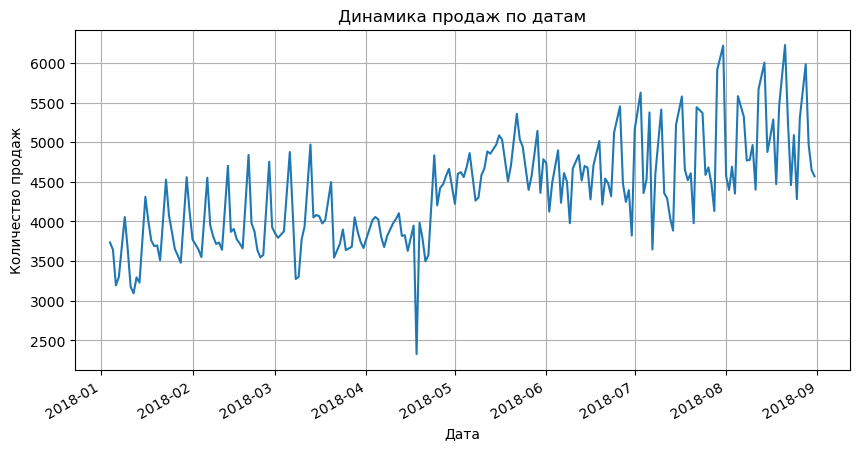

In [54]:
plt.figure(figsize=(10,5))
grouped_df.plot()
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике отображена динамика количества продаж по датам за период с января по сентябрь 2018 года.
В целом наблюдается восходящий тренд: в первые два месяца уровень продаж находится в диапазоне примерно 3200–4500, тогда как к августу значения достигают 5500–6200, что говорит о росте продаж со временем.
Также на графике явно выражены регулярные колебания, имеющие повторяющийся характер. Это может свидетельствовать о наличии сезонности внутри недели, например, различия между будними и выходными днями.

В районе середины апреля наблюдается резкий спад продаж до уровня около 2300, что является явным выбросом и сильно отличается от общего уровня значений. Начиная с июня увеличивается разброс значений, то есть колебания становятся более сильными,пики выше, а просадки заметнее. В июле–августе фиксируются максимальные значения продаж за весь период.

Таким образом, можно сделать вывод, что:
1. продажи имеют положительную динамику роста
2. присутствует регулярная сезонность
3. есть аномальные значения
4. а также наблюдается рост вариативности продаж со временем

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [55]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [56]:
filtered_df = df[(df['Дата'].dt.month.isin([6, 7, 8])) & (df['Дата'].dt.weekday == 2) & (df['Склад'] == 3)]
top_products = filtered_df.groupby('Номенклатура')['Количество'].sum().sort_values(ascending = False).reset_index()
top_products.head(1)

,Номенклатура,Количество
0,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [175]:
print(df['Дата'].min())
print(df['Дата'].max())

2018-01-04 00:00:00
2018-08-31 00:00:00


In [159]:
df_weather = pd.read_excel('погода.xlsx')

In [160]:
df_weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='str')

In [161]:
df_weather = df_weather.iloc[:, :2]

In [163]:
df_weather['Местное время в Астане'] = pd.to_datetime(df_weather['Местное время в Астане']).dt.normalize()

C:\Users\Leap\AppData\Local\Temp\ipykernel_12828\6158629.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather['Местное время в Астане'] = pd.to_datetime(df_weather['Местное время в Астане']).dt.normalize()


In [165]:
df_weather = df_weather.rename(columns={'Местное время в Астане': 'Дата'})

In [171]:
df_weather_daily = df_weather.groupby('Дата', as_index=False)['T'].mean()

In [169]:
grouped_df = grouped_df.iloc[:, 2:]

In [172]:
df_final = grouped_df.merge(df_weather_daily, on='Дата', how='left')

In [173]:
df_final

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500
...,...,...,...
200,2018-08-26,5302,11.9750
201,2018-08-28,5983,14.1125
202,2018-08-29,4969,13.8250
203,2018-08-30,4648,14.1750


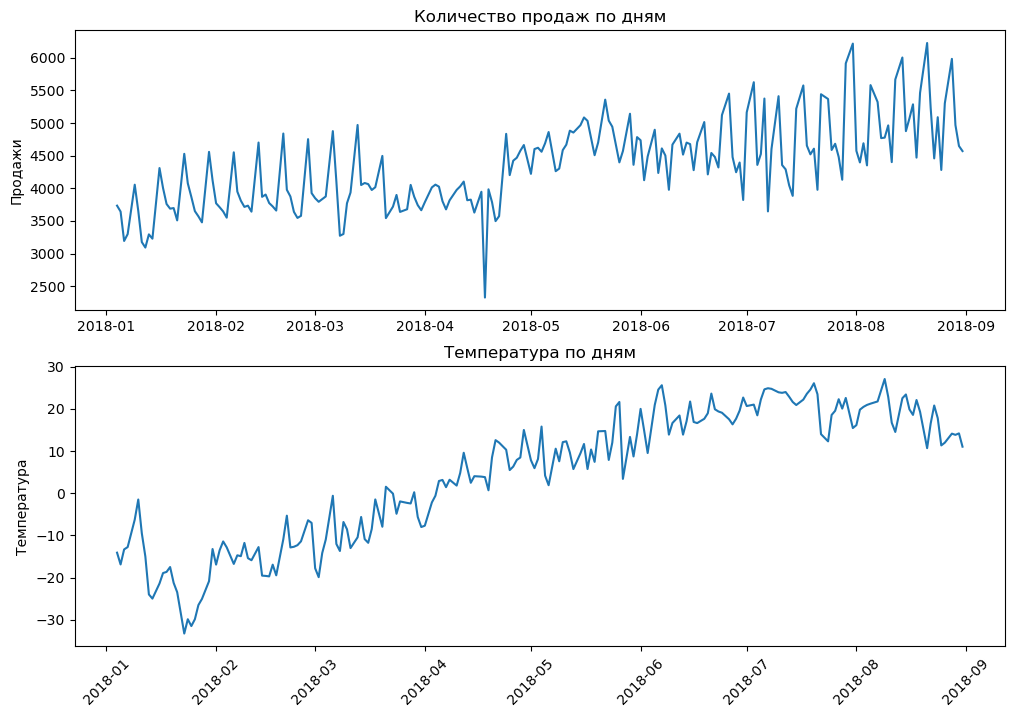

In [187]:
plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.plot(df_final['Дата'], df_final['Количество'])
plt.title('Количество продаж по дням')
plt.ylabel('Продажи')

plt.subplot(2,1,2)
plt.plot(df_final['Дата'], df_final['T'])
plt.title('Температура по дням')
plt.ylabel('Температура')

plt.xticks(rotation=45)

plt.show()

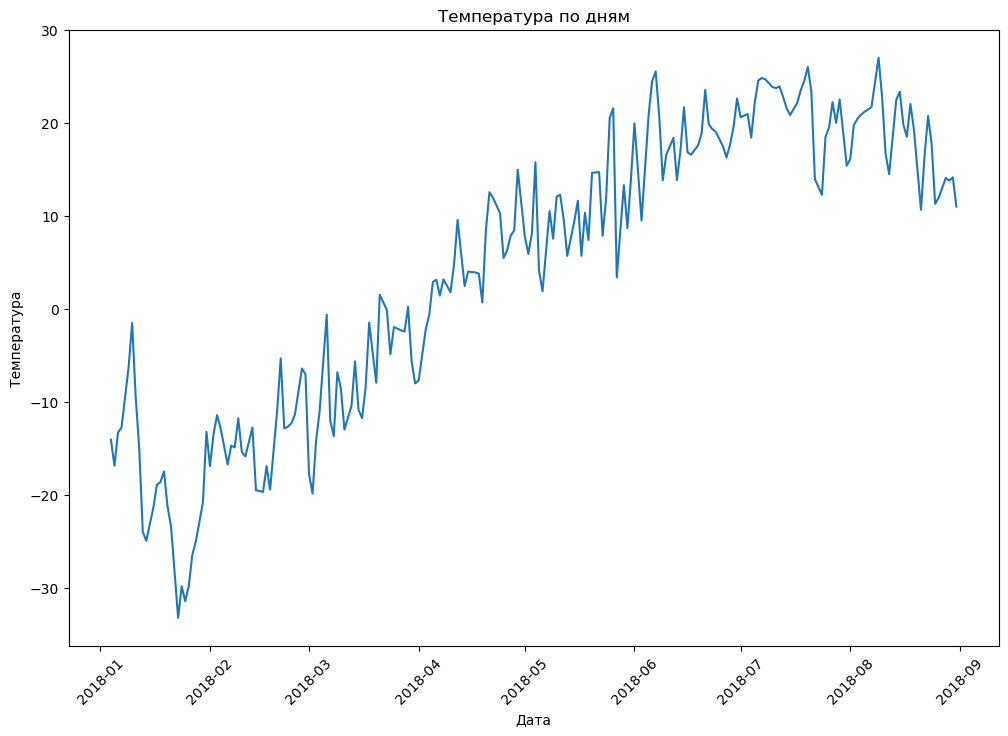

In [188]:
plt.figure(figsize=(12,8))
plt.plot(df_final['Дата'], df_final['T'])

plt.title('Температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.xticks(rotation=45)

plt.show()